### IMPORTAÇÕES


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

Definindo o tamanho da janela ou seja 200hz são 200 amostras por segundo

In [ ]:
tamanho_janela = 200 # 200 amostras = 1 segundo (ajuste para a taxa do ESP32)

Lendo os arquivos CSV's

In [7]:
df = pd.read_csv('../Dados_Ventilador_Normal_3Velocidades/dados_valores_xyz_puro.csv') 
df_porca_frouxa = pd.read_csv('../Dados_Ventilador_Normal_3Velocidades/Dados_Ventilador_PorcaFrouxa_3Velocidades/Dados_Ventilador_PorcaFrouxa_3Velocidades/dados_valores_xyz_puro.csv')
df_fita = pd.read_csv('../Dados_Ventilador_Normal_3Velocidades/Dados_Ventilador_FitaHelice_3Velocidades/Dados_Ventilador_FitaHelice_3Velocidades/dados_valores_xyz_puro.csv')

Criando o Dataframe por janela de chunk ou seja cada segundo tera o seu indice correspondente 

Por exemplo 

- Segundo 1 terá 200 linhas com id 0 
- Segundo 2 terá 200 linhas com id 1

In [ ]:
# Cria um ID sequencial para cada bloco de 200 linhas
# As linhas de índice 0 a 199 recebem o ID 0. As linhas 200 a 399 recebem o ID 1, etc.
df['chunk_id'] = np.arange(len(df)) // tamanho_janela
df.reset_index(drop=True, inplace=True) 

df_porca_frouxa['chunk_id'] = np.arange(len(df_porca_frouxa)) // tamanho_janela
df_porca_frouxa.reset_index(drop=True, inplace=True) 

df_fita['chunk_id'] = np.arange(len(df_fita)) // tamanho_janela
df_fita.reset_index(drop=True, inplace=True) 

In [9]:
df.head(5)

,x,y,z,chunk_id
0,10.19691,-1.386243,-0.126893,0
1,10.24239,-1.374272,-0.148441,0
2,10.22564,-1.422156,-0.102951,0
3,10.20169,-1.364695,-0.196325,0
4,10.26394,-1.364695,-0.107739,0


In [10]:
df_porca_frouxa.head(5)

,x,y,z,chunk_id
0,10.963050,-0.318429,0.110133,0
1,9.897630,-1.055843,-0.004788,0
2,10.398020,-0.893037,1.003170,0
3,10.785880,-0.158017,-0.663194,0
4,9.528923,-0.988805,0.320823,0


In [11]:
df_fita.head(5)

,x,y,z,chunk_id
0,11.133040,-1.838747,0.617704,0
1,9.904813,-2.051831,0.426168,0
2,10.625470,-0.986411,0.780510,0
3,10.350130,-2.422932,1.187524,0
4,9.718064,-1.790863,0.878672,0


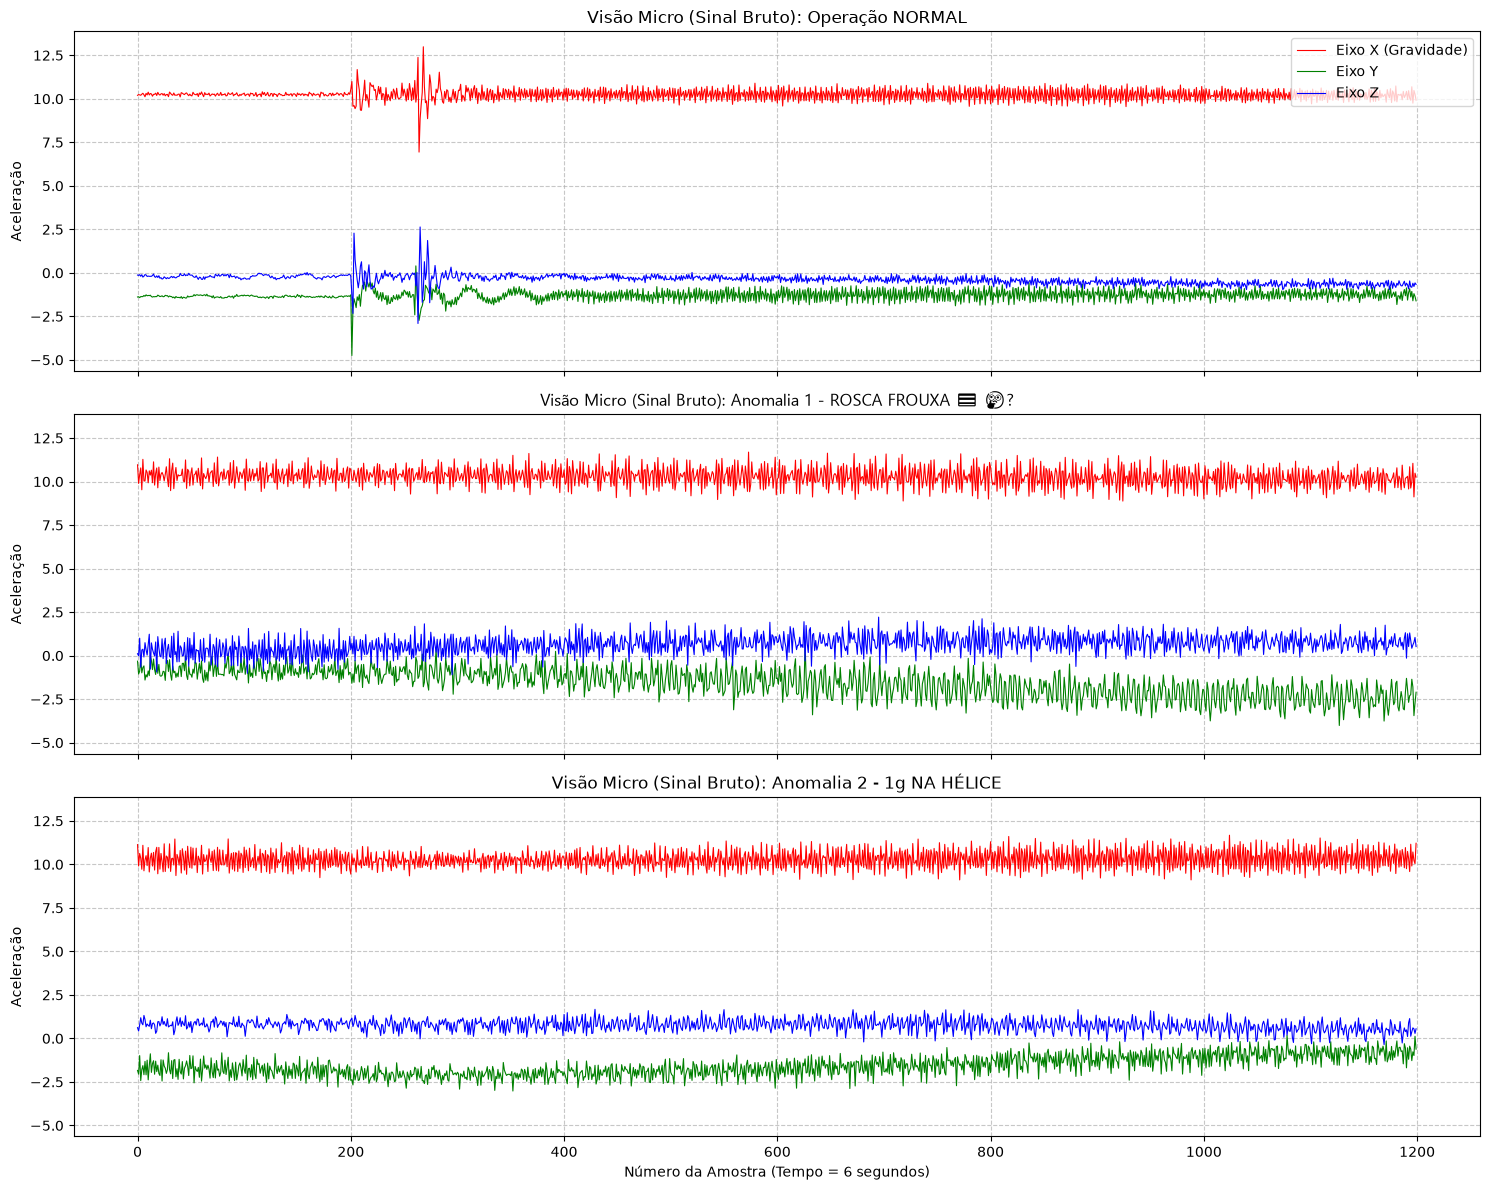

In [28]:
# 1. Selecionando as primeiras 1200 linhas (6 segundos) de CADA dataframe
amostra_normal = df.head(1200)
amostra_porca = df_porca_frouxa.head(1200)
amostra_fita = df_fita.head(1200)

# 2. Configurando a figura com 3 subplots (3 linhas, 1 coluna)
# sharex=True (mesmo eixo de tempo) e sharey=True (mesma escala de força)
fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharex=True, sharey=True)

# ================= LINHA 1: NORMALIDADE =================
axs[0].plot(amostra_normal.index, amostra_normal['x'], label='Eixo X (Gravidade)', color='red', linewidth=0.8)
axs[0].plot(amostra_normal.index, amostra_normal['y'], label='Eixo Y', color='green', linewidth=0.8)
axs[0].plot(amostra_normal.index, amostra_normal['z'], label='Eixo Z', color='blue', linewidth=0.8)
axs[0].set_title('Visão Micro (Sinal Bruto): Operação NORMAL', fontsize=12)
axs[0].set_ylabel('Aceleração')
axs[0].legend(loc='upper right') # Colocamos a legenda só no primeiro para não poluir
axs[0].grid(True, linestyle='--', alpha=0.7)

# ================= LINHA 2: PORCA FROUXA =================
axs[1].plot(amostra_porca.index, amostra_porca['x'], color='red', linewidth=0.8)
axs[1].plot(amostra_porca.index, amostra_porca['y'], color='green', linewidth=0.8)
axs[1].plot(amostra_porca.index, amostra_porca['z'], color='blue', linewidth=0.8)
axs[1].set_title('Visão Micro (Sinal Bruto): Anomalia 1 - ROSCA FROUXA 🏳️‍🌈 🤔?', fontsize=12, fontname='Segoe UI Emoji')
axs[1].set_ylabel('Aceleração')
axs[1].grid(True, linestyle='--', alpha=0.7)

# ================= LINHA 3: PESO NA HÉLICE =================
axs[2].plot(amostra_fita.index, amostra_fita['x'], color='red', linewidth=0.8)
axs[2].plot(amostra_fita.index, amostra_fita['y'], color='green', linewidth=0.8)
axs[2].plot(amostra_fita.index, amostra_fita['z'], color='blue', linewidth=0.8)
axs[2].set_title('Visão Micro (Sinal Bruto): Anomalia 2 - 1g NA HÉLICE', fontsize=12)
axs[2].set_xlabel('Número da Amostra (Tempo = 6 segundos)')
axs[2].set_ylabel('Aceleração')
axs[2].grid(True, linestyle='--', alpha=0.7)

# Ajuste automático de espaçamento para ficar bonito
plt.tight_layout()
plt.show()

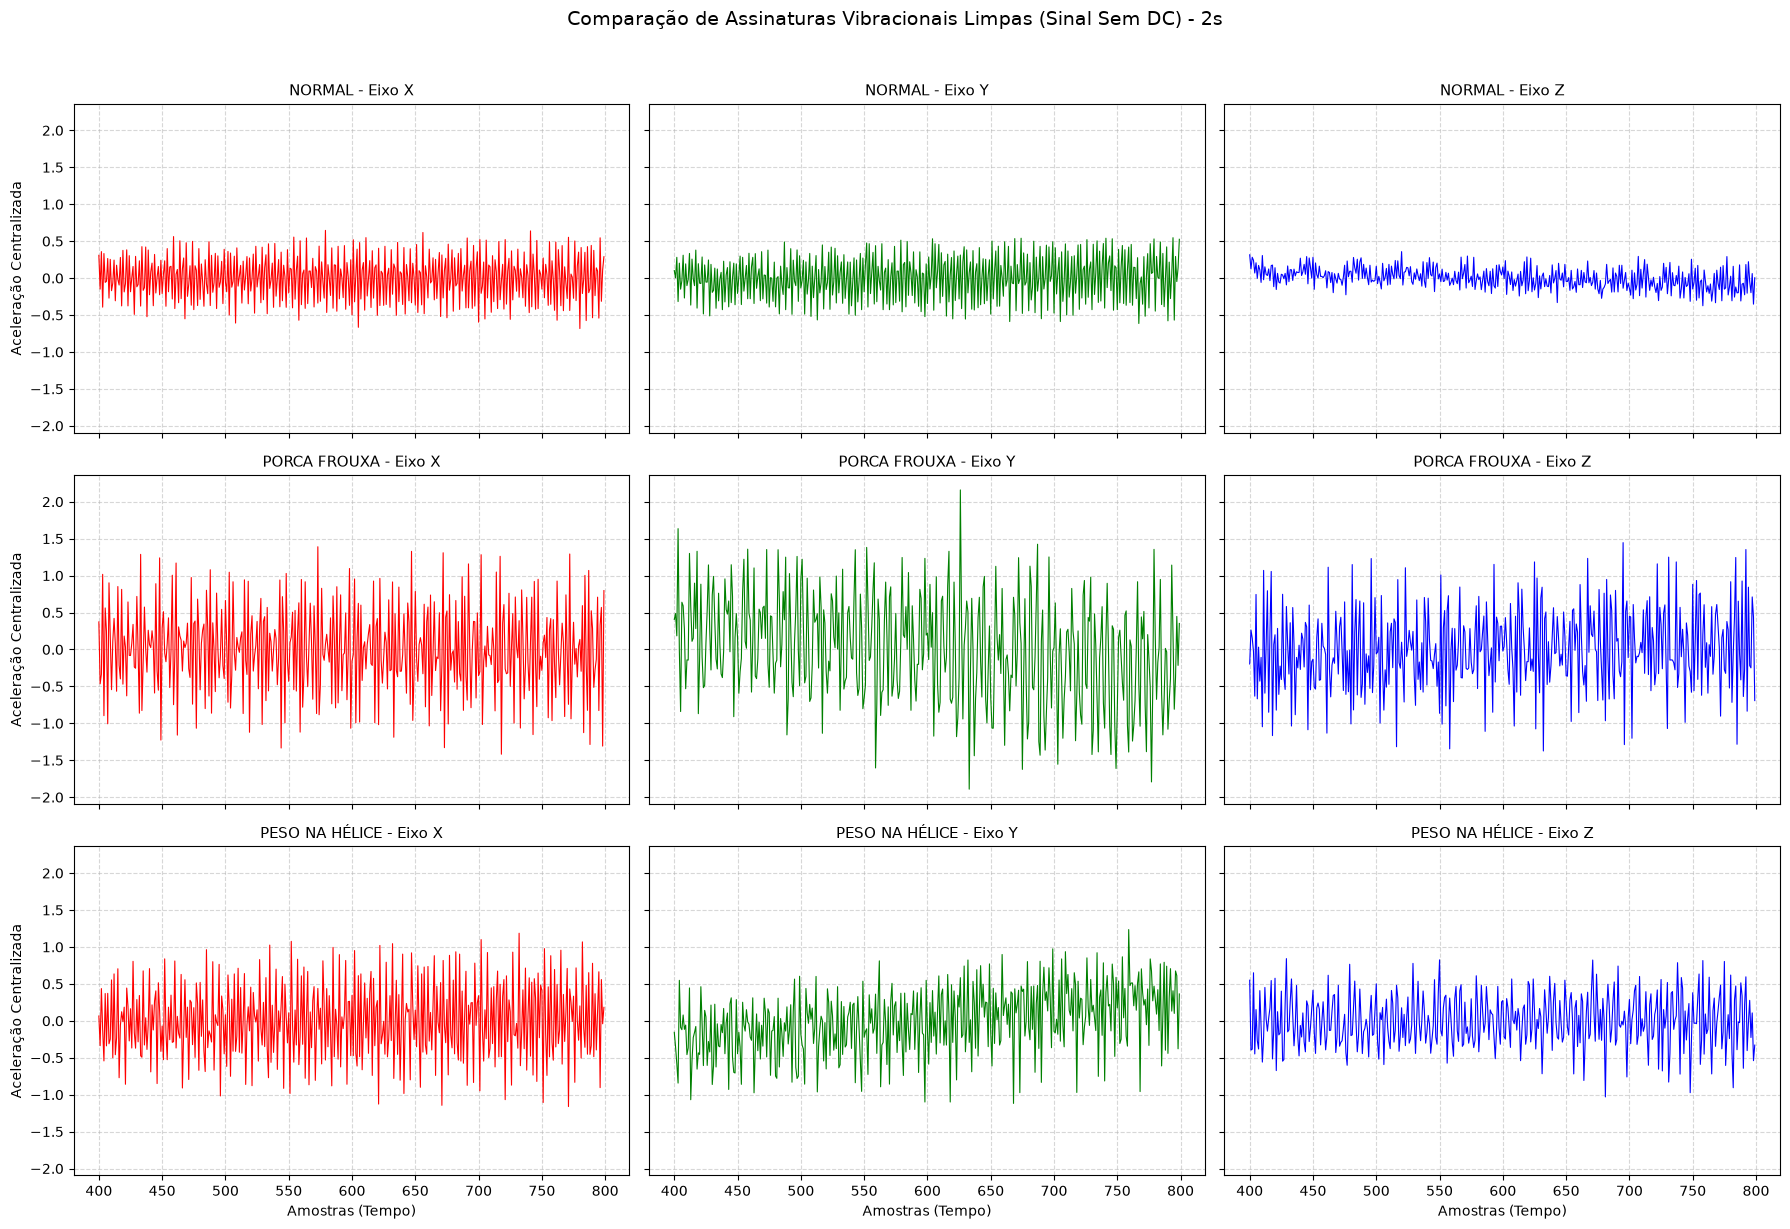

In [39]:
# ==============================================================================
# 1. SELEÇÃO E LIMPEZA DOS DADOS (Remoção da Gravidade / DC)
# ==============================================================================
# Pegamos as 1200 amostras (6 segundos) de cada cenário
amostra_normal = df.iloc[400:800].copy()
amostra_porca = df_porca_frouxa.iloc[400:800].copy()
amostra_fita = df_fita.iloc[400:800].copy()

# Criamos uma função rápida para subtrair a média (limpar o DC) de todos os eixos de uma vez
def centralizar_sinal(amostra):
    limpo = pd.DataFrame()
    for eixo in ['x', 'y', 'z']:
        limpo[eixo] = amostra[eixo] - amostra[eixo].mean()
    return limpo

# Aplicamos a limpeza gerando os 3 dataframes definitivos para o plot
limpo_normal = centralizar_sinal(amostra_normal)
limpo_porca = centralizar_sinal(amostra_porca)
limpo_fita = centralizar_sinal(amostra_fita)

# ==============================================================================
# 2. CRIAÇÃO DA MATRIZ DE GRÁFICOS (3 Linhas x 3 Colunas)
# ==============================================================================
# sharex=True e sharey=True garantem que o tempo e a escala de força sejam idênticos para todos
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey=True)

# Cores padronizadas para cada eixo
cor_x, cor_y, cor_z = 'red', 'green', 'blue'

# --- LINHA 1: OPERAÇÃO NORMAL ---
axs[0, 0].plot(limpo_normal.index, limpo_normal['x'], color=cor_x, linewidth=0.8)
axs[0, 0].set_title('NORMAL - Eixo X', fontsize=11)
axs[0, 0].set_ylabel('Aceleração Centralizada')

axs[0, 1].plot(limpo_normal.index, limpo_normal['y'], color=cor_y, linewidth=0.8)
axs[0, 1].set_title('NORMAL - Eixo Y', fontsize=11)

axs[0, 2].plot(limpo_normal.index, limpo_normal['z'], color=cor_z, linewidth=0.8)
axs[0, 2].set_title('NORMAL - Eixo Z', fontsize=11)

# --- LINHA 2: PORCA FROUXA ---
axs[1, 0].plot(limpo_porca.index, limpo_porca['x'], color=cor_x, linewidth=0.8)
axs[1, 0].set_title('PORCA FROUXA - Eixo X', fontsize=11)
axs[1, 0].set_ylabel('Aceleração Centralizada')

axs[1, 1].plot(limpo_porca.index, limpo_porca['y'], color=cor_y, linewidth=0.8)
axs[1, 1].set_title('PORCA FROUXA - Eixo Y', fontsize=11)

axs[1, 2].plot(limpo_porca.index, limpo_porca['z'], color=cor_z, linewidth=0.8)
axs[1, 2].set_title('PORCA FROUXA - Eixo Z', fontsize=11)

# --- LINHA 3: PESO 1g NA HÉLICE ---
axs[2, 0].plot(limpo_fita.index, limpo_fita['x'], color=cor_x, linewidth=0.8)
axs[2, 0].set_title('PESO NA HÉLICE - Eixo X', fontsize=11)
axs[2, 0].set_ylabel('Aceleração Centralizada')
axs[2, 0].set_xlabel('Amostras (Tempo)')

axs[2, 1].plot(limpo_fita.index, limpo_fita['y'], color=cor_y, linewidth=0.8)
axs[2, 1].set_title('PESO NA HÉLICE - Eixo Y', fontsize=11)
axs[2, 1].set_xlabel('Amostras (Tempo)')

axs[2, 2].plot(limpo_fita.index, limpo_fita['z'], color=cor_z, linewidth=0.8)
axs[2, 2].set_title('PESO NA HÉLICE - Eixo Z', fontsize=11)
axs[2, 2].set_xlabel('Amostras (Tempo)')

# Aplica uma grade de fundo a todos os 9 gráficos automaticamente
for ax in axs.flat:
    ax.grid(True, linestyle='--', alpha=0.5)

# Título geral e ajustes de espaçamento
plt.suptitle('Comparação de Assinaturas Vibracionais Limpas (Sinal Sem DC) - 2s', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

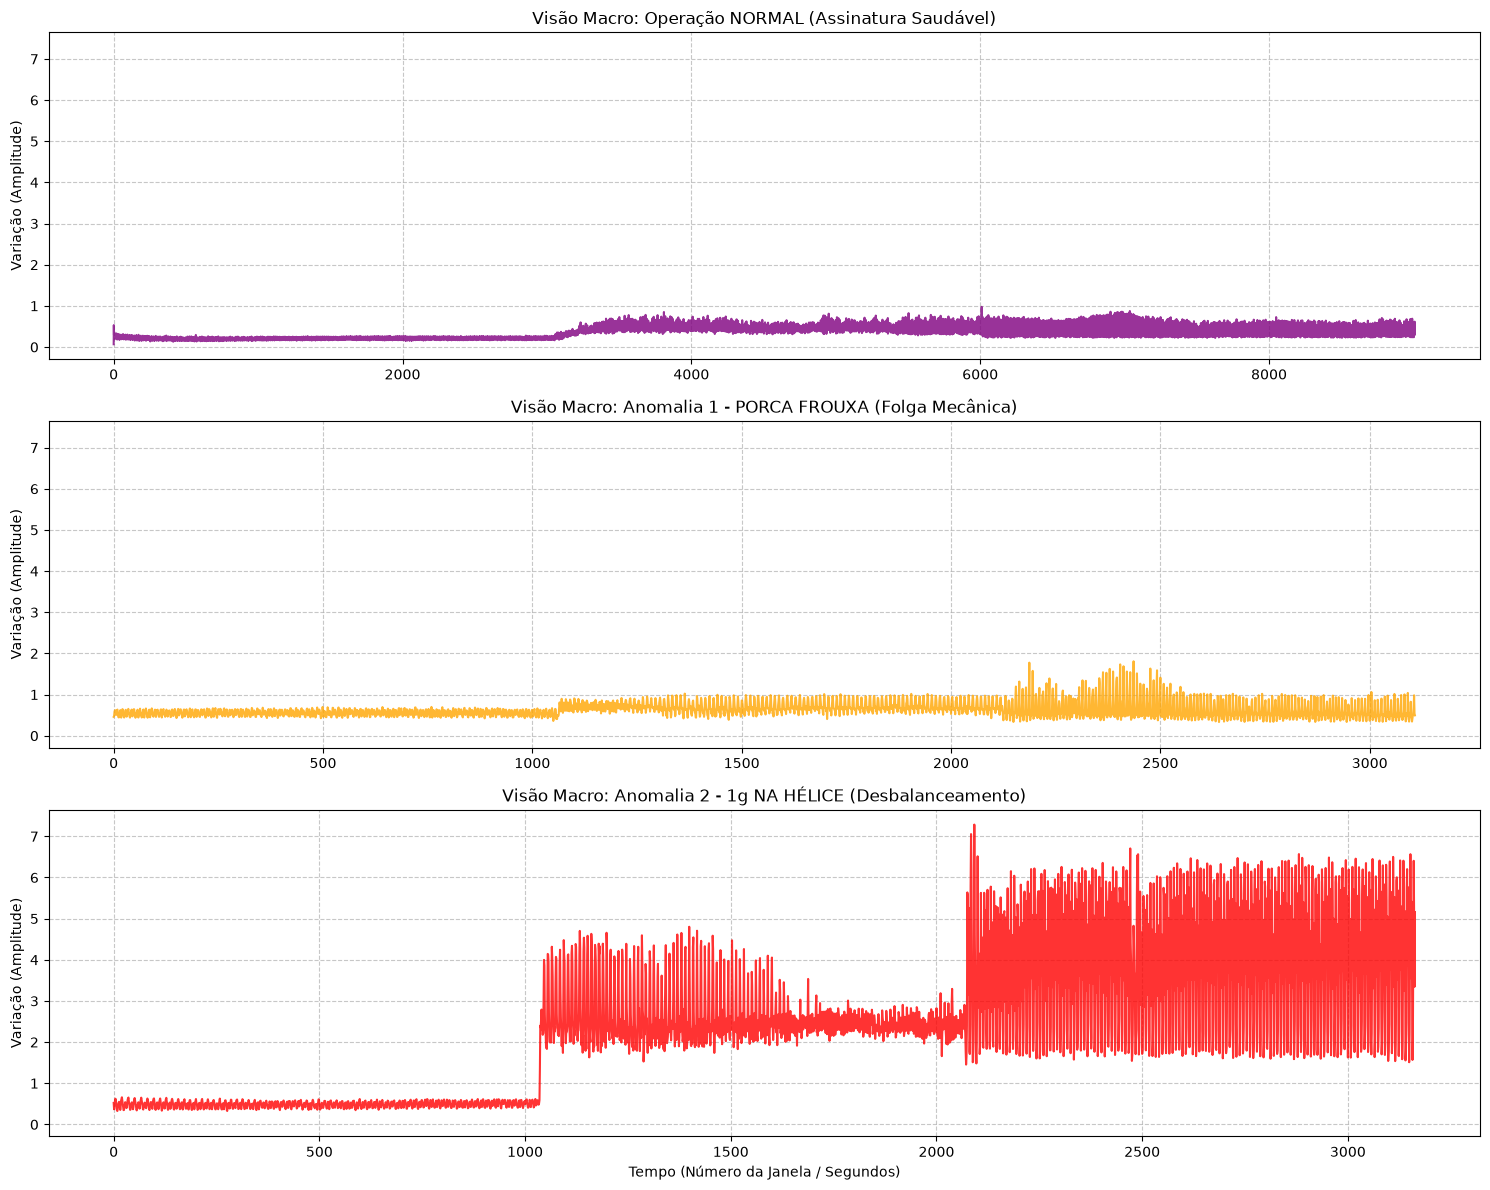

In [20]:
# 1. Calculando a intensidade (Desvio Padrão) para o Eixo X de cada um dos 3 cenários
intensidade_normal = df.groupby('chunk_id')['x'].std()
intensidade_porca = df_porca_frouxa.groupby('chunk_id')['x'].std()
intensidade_fita = df_fita.groupby('chunk_id')['x'].std()

# 2. Criando a figura com 3 linhas e 1 coluna
# sharey=True é OBRIGATÓRIO para garantir que 1G de força no gráfico 1 seja visualmente igual a 1G no gráfico 3
fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharey=True, sharex=False)

# ================= LINHA 1: NORMALIDADE =================
axs[0].plot(intensidade_normal.index, intensidade_normal.values, color='purple', alpha=0.8)
axs[0].set_title('Visão Macro: Operação NORMAL (Assinatura Saudável)', fontsize=12)
axs[0].set_ylabel('Variação (Amplitude)')
axs[0].grid(True, linestyle='--', alpha=0.7)

# ================= LINHA 2: PORCA FROUXA =================
axs[1].plot(intensidade_porca.index, intensidade_porca.values, color='orange', alpha=0.8)
axs[1].set_title('Visão Macro: Anomalia 1 - PORCA FROUXA (Folga Mecânica)', fontsize=12)
axs[1].set_ylabel('Variação (Amplitude)')
axs[1].grid(True, linestyle='--', alpha=0.7)

# ================= LINHA 3: PESO NA HÉLICE =================
axs[2].plot(intensidade_fita.index, intensidade_fita.values, color='red', alpha=0.8)
axs[2].set_title('Visão Macro: Anomalia 2 - 1g NA HÉLICE (Desbalanceamento)', fontsize=12)
axs[2].set_xlabel('Tempo (Número da Janela / Segundos)')
axs[2].set_ylabel('Variação (Amplitude)')
axs[2].grid(True, linestyle='--', alpha=0.7)

# Ajuste visual e exibição
plt.tight_layout()
plt.show()

ANALISE AGRUPADA 

---



- **Amplitude Máxima:** É literalmente o ponto mais alto que a vibração alcançou. Se o gráfico do sensor subiu até o número 3, a amplitude máxima é 3. Mostra o solavanco mais forte daquele segundo.

- **Range (Alcance):** É a distância total entre o ponto mais baixo e o ponto mais alto. Se a vibração foi do -2 ao +3, o range é 5 (porque andou 5 "casas" no gráfico).

- **RMS:** É o tamanho médio da vibração. Como o ventilador balança para valores positivos (para cima) e negativos (para baixo), se fizéssemos uma média normal, o resultado seria zero e a conta daria errado. O RMS é só um truque matemático para ignorar o sinal de "menos" e calcular a média. Dizer que "o RMS é 1.5" significa apenas que, em média, o tamanho da vibração do motor é 1.5.

- **Desvio Padrão:** É o quanto a vibração varia e se afasta do centro (zero). Na prática, para o seu projeto, ele dá um resultado quase idêntico ao RMS e serve para a mesma coisa: mostrar o volume da vibração.

- **Curtose:** É o medidor de trancos e solavancos isolados. Se o ventilador treme sempre do mesmo jeito, a curtose fica perto de zero. Se de repente ele der um "tranco" seco ou uma "pancada" fora do ritmo, esse número sobe muito.

In [41]:

# 1. Definimos uma função que recebe um único 'chunk' (uma tabela de 200 linhas)
def extrair_features(chunk):
    # Dicionário vazio para guardar os resultados deste segundo
    features = {} 
    
    # 2. Fazemos o processo automaticamente para os 3 eixos (x, y, z)
    for eixo in ['x', 'y', 'z']:
        
        # A) REMOÇÃO DO DC (Gravidade):
        # Subtraímos a média do chunk para o sinal oscilar no zero.
        # Fisicamente: Removemos o peso da gravidade (10.2 do eixo X).
        sinal_limpo = chunk[eixo] - chunk[eixo].mean()

        features[f'{eixo}_mean'] = sinal_limpo.mean()  # Apenas para conferência, não é uma feature útil.
        
        # B) EXTRAÇÃO DE FEATURES (Comportamento Físico):
        
        # 1. Desvio Padrão (Standard Deviation)
        # O que é: O quão espalhados os dados estão em relação ao zero.
        # Física: A intensidade global da trepidação. (Já o usamos nos gráficos).
        features[f'{eixo}_std'] = sinal_limpo.std()
        
        # 2. RMS (Root Mean Square / Média Quadrática)
        # O que é: A raiz da média dos valores ao quadrado. Como eleva ao quadrado, 
        # os valores negativos (a vibração "para baixo") viram positivos e somam-se.
        # Física: A energia contínua e o desgaste mecânico geral da máquina. 
        # (É a norma ISO usada na indústria para manutenção preditiva).
        features[f'{eixo}_rms'] = np.sqrt(np.mean(sinal_limpo**2))
        
        # 3. Curtose (Kurtosis)
        # O que é: Mede se existem valores "muito extremos" (caudas longas).
        # Física: Mede a ocorrência de impactos pontuais repetitivos. 
        # Ex: Se um rolamento estourou e há uma "pancada" metálica a cada giro, 
        # a Curtose dispara, mesmo que o RMS continue normal.
        features[f'{eixo}_kurtosis'] = kurtosis(sinal_limpo)
        
        # 4. Amplitude Máxima Absoluta
        # O que é: O maior pico (positivo ou negativo) registrado naquele segundo.
        # Física: O "solavanco" mais violento que a carcaça sofreu na janela.
        features[f'{eixo}_max_amp'] = np.max(np.abs(sinal_limpo))
        
        # 5. Range (Alcance Máximo)
        # O que é: O valor máximo menos o valor mínimo.
        # Física: A distância total percorrida pelo chassi da máquina no movimento 
        # de "vai-e-vem" da vibração.
        features[f'{eixo}_range'] = np.max(sinal_limpo) - np.min(sinal_limpo)
        
    # Devolvemos uma única linha contendo as 15 features (5 para cada um dos 3 eixos)
    return pd.Series(features)


In [42]:
# 1. Aplicamos a função de extração aos 3 DataFrames
print("Extraindo features do cenário NORMAL...")
features_normal = df.groupby('chunk_id').apply(extrair_features).reset_index()

print("Extraindo features do cenário PORCA FROUXA...")
features_porca = df_porca_frouxa.groupby('chunk_id').apply(extrair_features).reset_index()

print("Extraindo features do cenário FITA NA HÉLICE...")
features_fita = df_fita.groupby('chunk_id').apply(extrair_features).reset_index()


Extraindo features do cenário NORMAL...
Extraindo features do cenário PORCA FROUXA...
Extraindo features do cenário FITA NA HÉLICE...


In [48]:
# 2. Adicionamos a Etiqueta (Label) para Machine Learning
# 0 = Normal / 1 = Anomalia
features_normal['label'] = 0
features_normal['tipo_falha'] = 'normal'

features_porca['label'] = 1
features_porca['tipo_falha'] = 'porca_frouxa'

features_fita['label'] = 1
features_fita['tipo_falha'] = 'fita_helice'

In [49]:
features_normal.head(5)

,chunk_id,x_mean,x_std,x_rms,x_kurtosis,x_max_amp,x_range,y_mean,y_std,y_rms,...,y_max_amp,y_range,z_mean,z_std,z_rms,z_kurtosis,z_max_amp,z_range,label,tipo_falha
0,0,1.030287e-15,0.067595,0.067426,-0.525439,0.159023,0.311250,-1.376677e-16,0.051734,0.051605,...,0.131490,0.248997,-1.096345e-17,0.090543,0.090317,-0.634533,0.225845,0.426168,0,normal
1,1,-1.820766e-16,0.532018,0.530686,10.907360,3.316173,6.050144,6.883383e-17,0.452813,0.451679,...,3.412456,5.147534,2.275957e-17,0.505479,0.504214,13.578808,2.858096,5.544971,0,normal
2,2,-1.492140e-15,0.301027,0.300274,-1.130053,0.641010,1.254560,-8.493206e-17,0.282842,0.282135,...,0.545639,1.079785,-2.442491e-17,0.123390,0.123081,-0.531558,0.310073,0.584185,0,normal
3,3,3.197442e-16,0.340127,0.339275,-1.210238,0.677990,1.321600,2.087219e-16,0.338823,0.337975,...,0.635241,1.161187,5.107026e-17,0.153122,0.152739,-0.667682,0.341880,0.667982,0,normal
4,4,-4.707346e-16,0.364063,0.363152,-1.262147,0.678337,1.338362,-6.661338e-18,0.320471,0.319668,...,0.668712,1.288080,2.664535e-17,0.166950,0.166532,-0.617333,0.396336,0.768538,0,normal


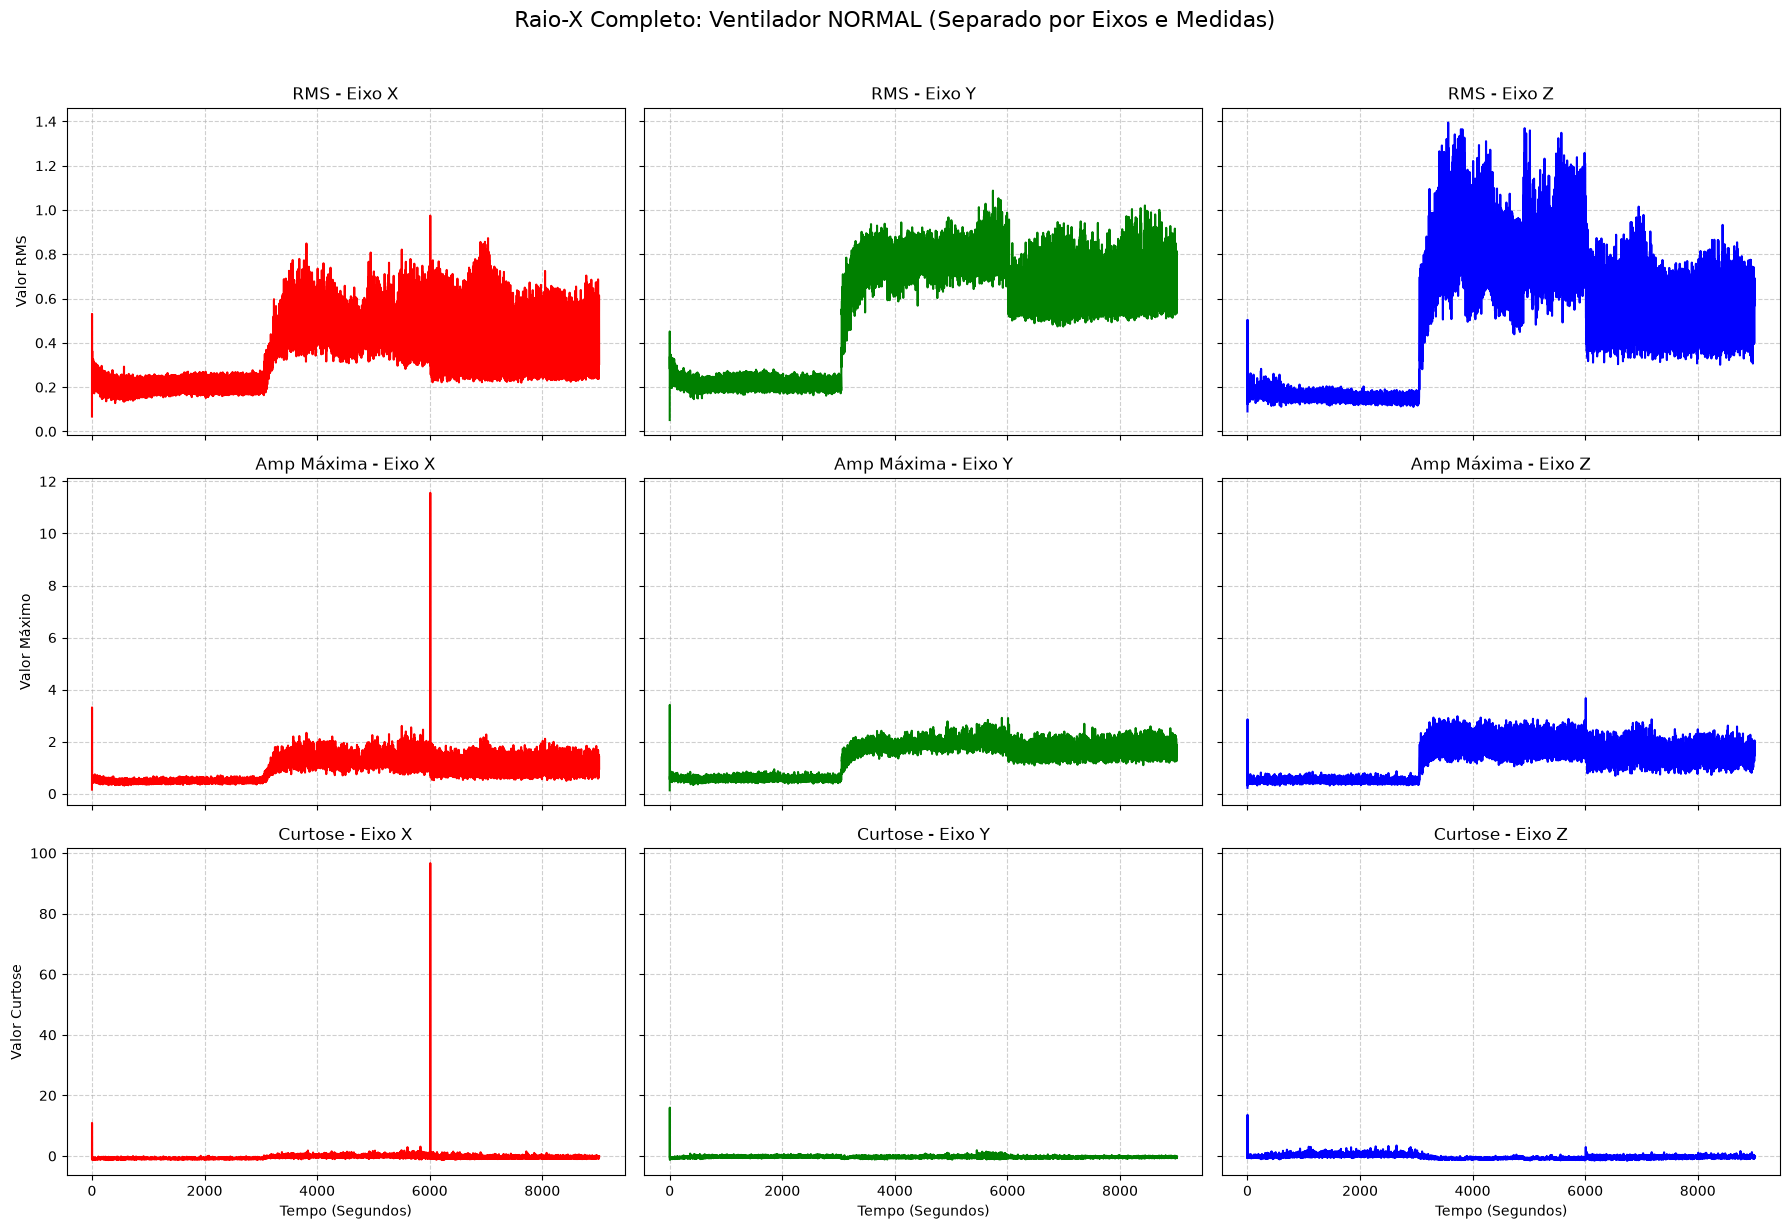

In [57]:
# Criação da figura com 3 linhas (Features) e 3 colunas (Eixos)
# sharex=True (mesmo tempo para todos) e sharey='row' (mesma escala de altura por feature)
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey='row')

# Cores padronizadas para facilitar a leitura
cor_x, cor_y, cor_z = 'red', 'green', 'blue'
tempo = features_normal['chunk_id']

# ==========================================================
# LINHA 1: TAMANHO MÉDIO DA VIBRAÇÃO (RMS)
# ==========================================================
axs[0, 0].plot(tempo, features_normal['x_rms'], color=cor_x)
axs[0, 0].set_title('RMS - Eixo X')
axs[0, 0].set_ylabel('Valor RMS')

axs[0, 1].plot(tempo, features_normal['y_rms'], color=cor_y)
axs[0, 1].set_title('RMS - Eixo Y')

axs[0, 2].plot(tempo, features_normal['z_rms'], color=cor_z)
axs[0, 2].set_title('RMS - Eixo Z')

# ==========================================================
# LINHA 2: PICO MÁXIMO DE VIBRAÇÃO (AMPLITUDE MÁXIMA)
# ==========================================================
axs[1, 0].plot(tempo, features_normal['x_max_amp'], color=cor_x)
axs[1, 0].set_title('Amp Máxima - Eixo X')
axs[1, 0].set_ylabel('Valor Máximo')

axs[1, 1].plot(tempo, features_normal['y_max_amp'], color=cor_y)
axs[1, 1].set_title('Amp Máxima - Eixo Y')

axs[1, 2].plot(tempo, features_normal['z_max_amp'], color=cor_z)
axs[1, 2].set_title('Amp Máxima - Eixo Z')

# ==========================================================
# LINHA 3: MEDIDOR DE TRANCOS (CURTOSE)
# ==========================================================
axs[2, 0].plot(tempo, features_normal['x_kurtosis'], color=cor_x)
axs[2, 0].set_title('Curtose - Eixo X')
axs[2, 0].set_xlabel('Tempo (Segundos)')
axs[2, 0].set_ylabel('Valor Curtose')

axs[2, 1].plot(tempo, features_normal['y_kurtosis'], color=cor_y)
axs[2, 1].set_title('Curtose - Eixo Y')
axs[2, 1].set_xlabel('Tempo (Segundos)')

axs[2, 2].plot(tempo, features_normal['z_kurtosis'], color=cor_z)
axs[2, 2].set_title('Curtose - Eixo Z')
axs[2, 2].set_xlabel('Tempo (Segundos)')

# Aplicando grade em todos os 9 gráficos
for ax in axs.flat:
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Raio-X Completo: Ventilador NORMAL (Separado por Eixos e Medidas)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

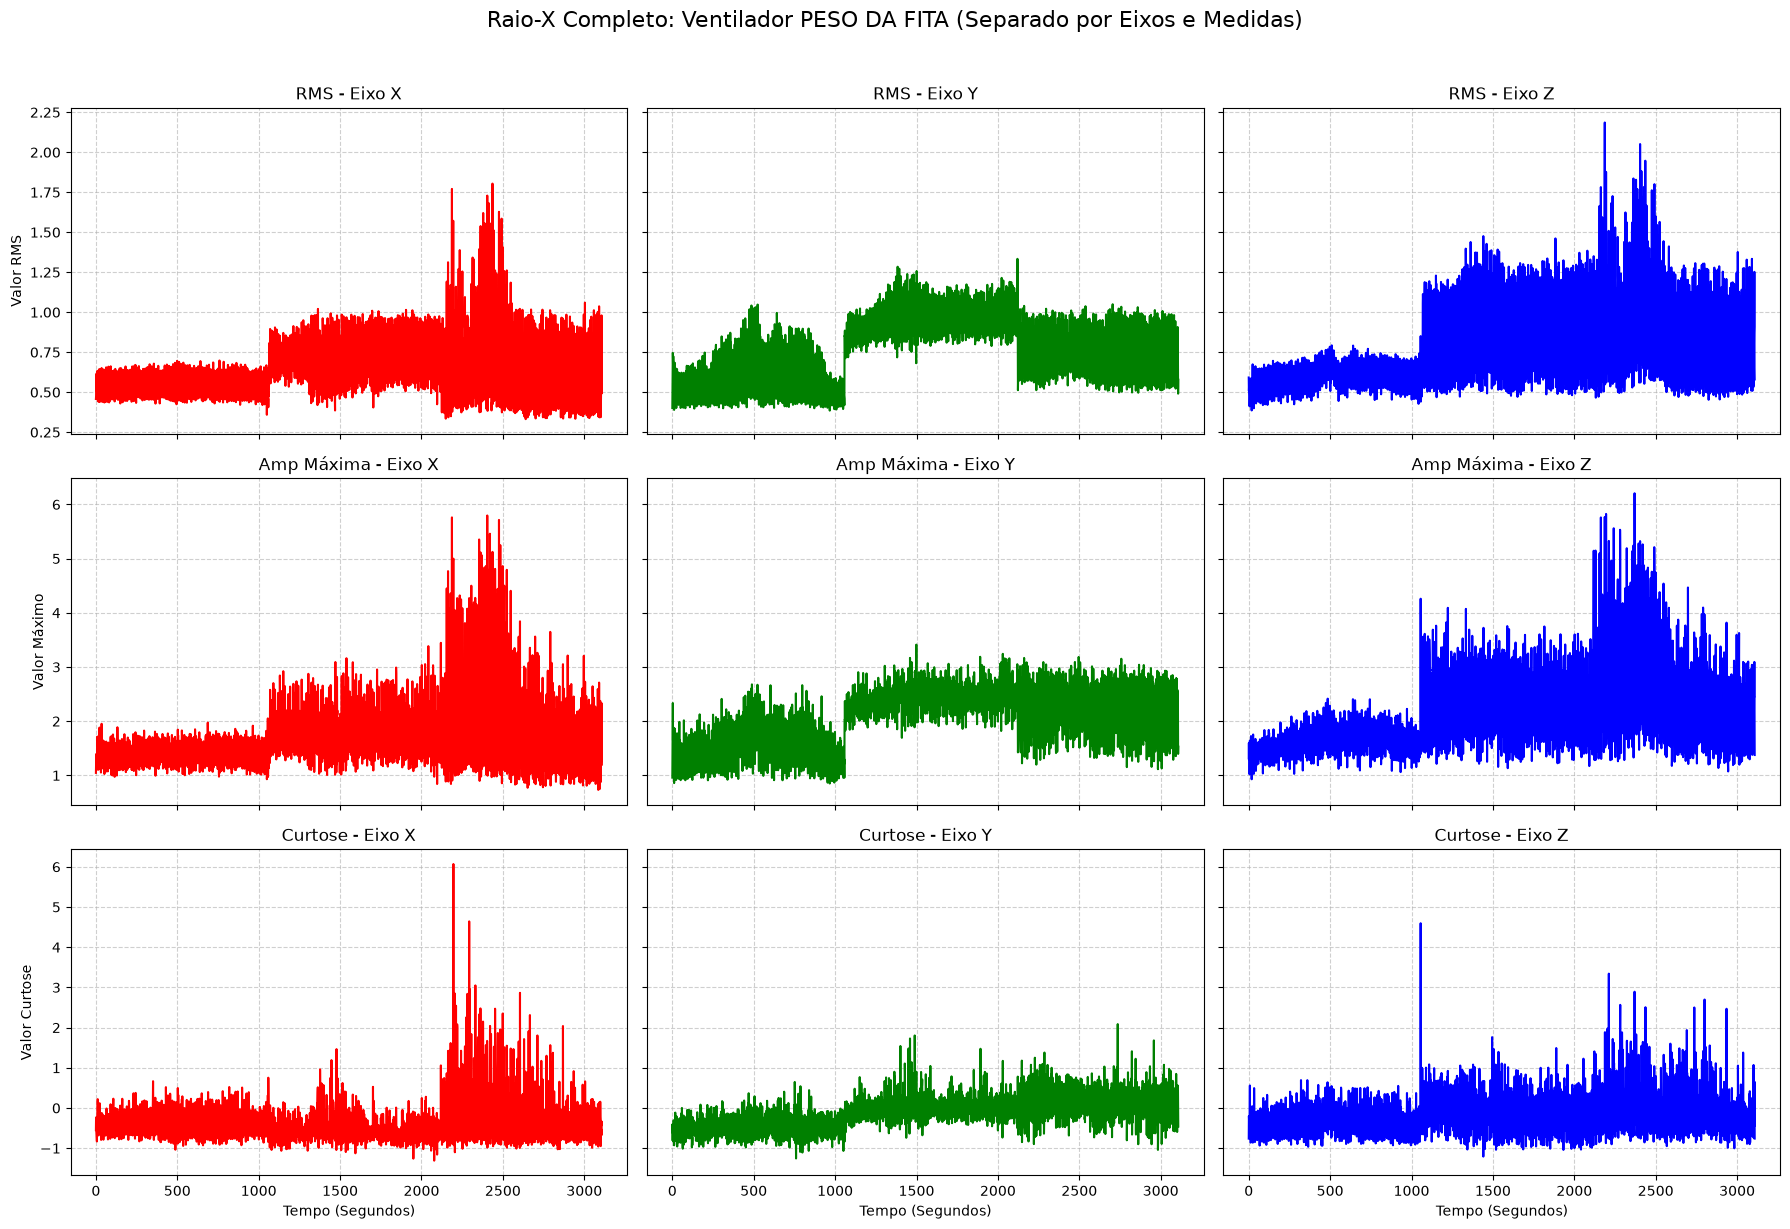

In [60]:
# Criação da figura com 3 linhas (Features) e 3 colunas (Eixos)
# sharex=True (mesmo tempo para todos) e sharey='row' (mesma escala de altura por feature)
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey='row')

# Cores padronizadas para facilitar a leitura
cor_x, cor_y, cor_z = 'red', 'green', 'blue'
tempo = features_porca['chunk_id']

# ==========================================================
# LINHA 1: TAMANHO MÉDIO DA VIBRAÇÃO (RMS)
# ==========================================================
axs[0, 0].plot(tempo, features_porca['x_rms'], color=cor_x)
axs[0, 0].set_title('RMS - Eixo X')
axs[0, 0].set_ylabel('Valor RMS')

axs[0, 1].plot(tempo, features_porca['y_rms'], color=cor_y)
axs[0, 1].set_title('RMS - Eixo Y')

axs[0, 2].plot(tempo, features_porca['z_rms'], color=cor_z)
axs[0, 2].set_title('RMS - Eixo Z')

# ==========================================================
# LINHA 2: PICO MÁXIMO DE VIBRAÇÃO (AMPLITUDE MÁXIMA)
# ==========================================================
axs[1, 0].plot(tempo, features_porca['x_max_amp'], color=cor_x)
axs[1, 0].set_title('Amp Máxima - Eixo X')
axs[1, 0].set_ylabel('Valor Máximo')

axs[1, 1].plot(tempo, features_porca['y_max_amp'], color=cor_y)
axs[1, 1].set_title('Amp Máxima - Eixo Y')

axs[1, 2].plot(tempo, features_porca['z_max_amp'], color=cor_z)
axs[1, 2].set_title('Amp Máxima - Eixo Z')

# ==========================================================
# LINHA 3: MEDIDOR DE TRANCOS (CURTOSE)
# ==========================================================
axs[2, 0].plot(tempo, features_porca['x_kurtosis'], color=cor_x)
axs[2, 0].set_title('Curtose - Eixo X')
axs[2, 0].set_xlabel('Tempo (Segundos)')
axs[2, 0].set_ylabel('Valor Curtose')

axs[2, 1].plot(tempo, features_porca['y_kurtosis'], color=cor_y)
axs[2, 1].set_title('Curtose - Eixo Y')
axs[2, 1].set_xlabel('Tempo (Segundos)')

axs[2, 2].plot(tempo, features_porca['z_kurtosis'], color=cor_z)
axs[2, 2].set_title('Curtose - Eixo Z')
axs[2, 2].set_xlabel('Tempo (Segundos)')

# Aplicando grade em todos os 9 gráficos
for ax in axs.flat:
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Raio-X Completo: Ventilador PESO DA FITA (Separado por Eixos e Medidas)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

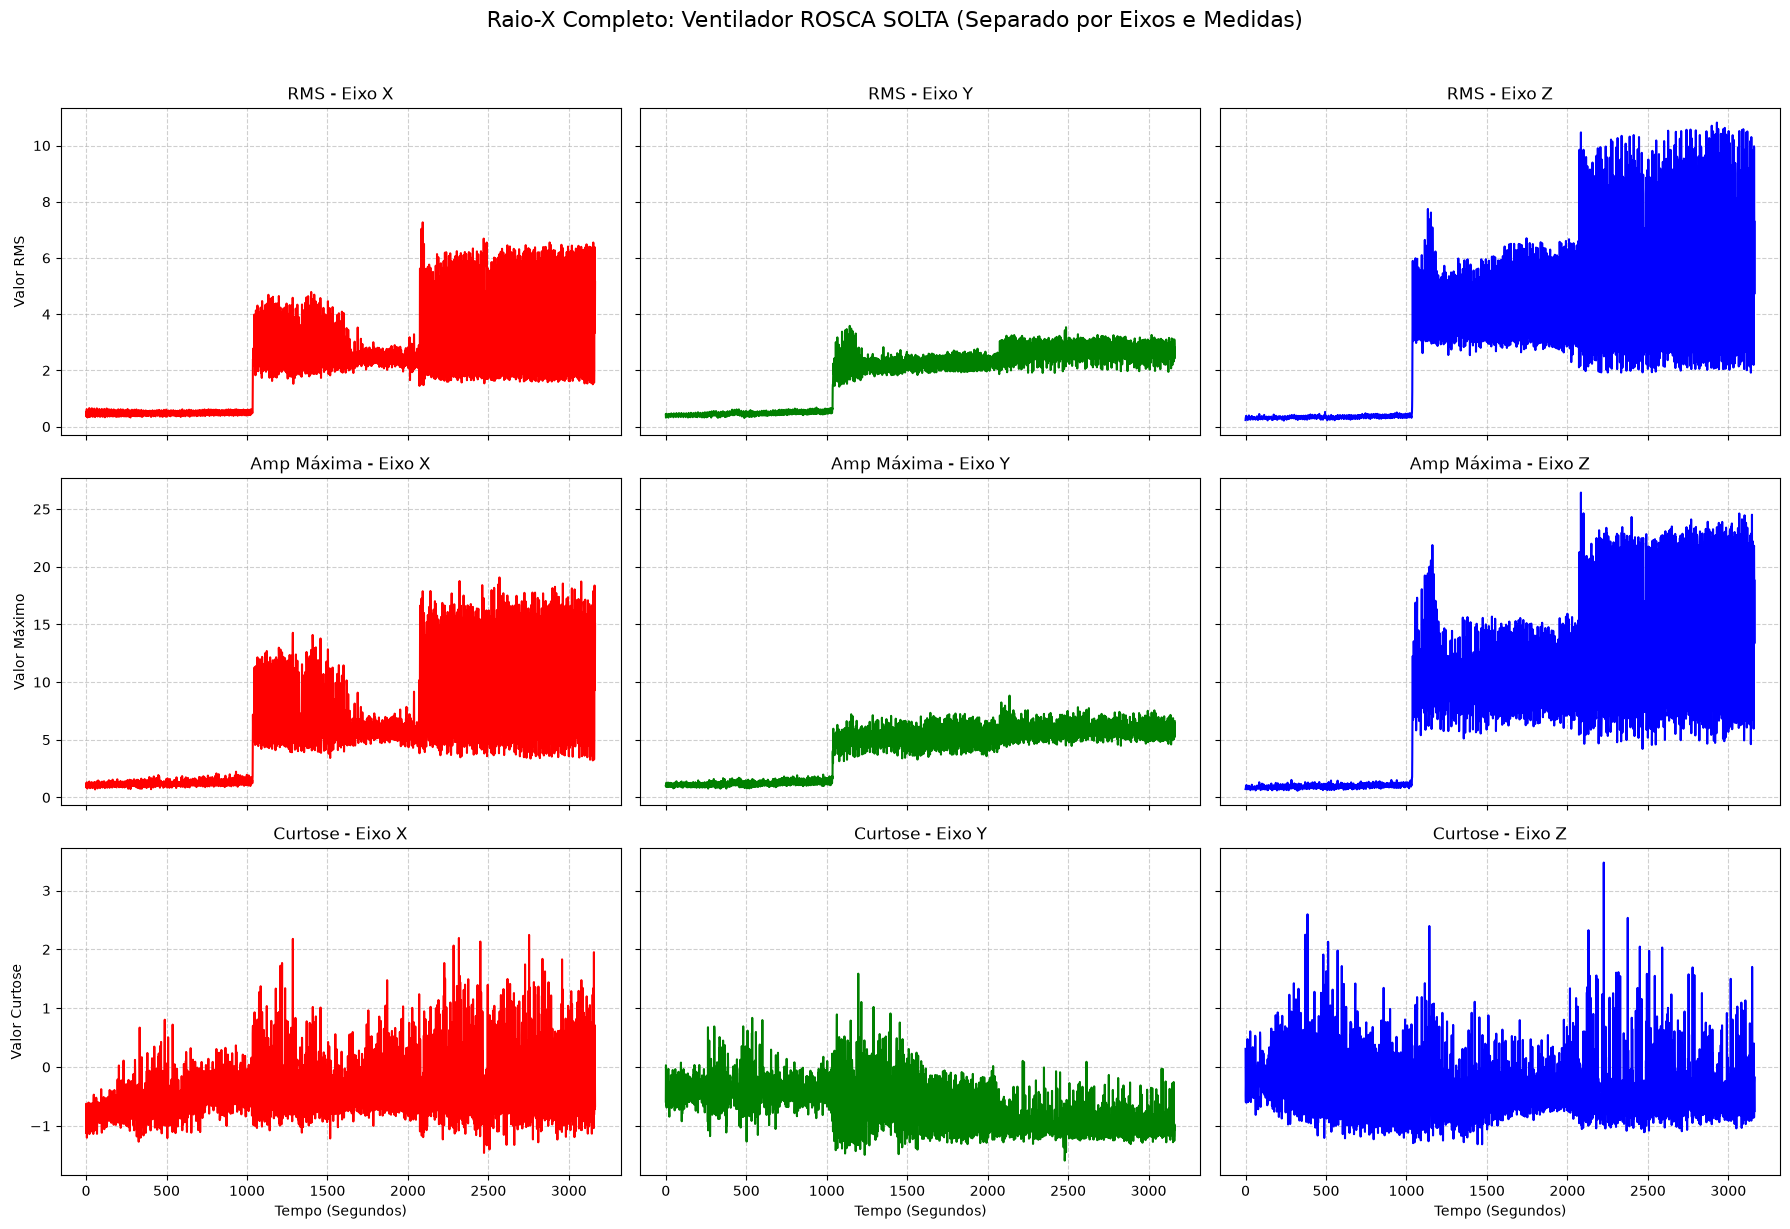

In [59]:
# Criação da figura com 3 linhas (Features) e 3 colunas (Eixos)
# sharex=True (mesmo tempo para todos) e sharey='row' (mesma escala de altura por feature)
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey='row')

# Cores padronizadas para facilitar a leitura
cor_x, cor_y, cor_z = 'red', 'green', 'blue'
tempo = features_fita['chunk_id']

# ==========================================================
# LINHA 1: TAMANHO MÉDIO DA VIBRAÇÃO (RMS)
# ==========================================================
axs[0, 0].plot(tempo, features_fita['x_rms'], color=cor_x)
axs[0, 0].set_title('RMS - Eixo X')
axs[0, 0].set_ylabel('Valor RMS')

axs[0, 1].plot(tempo, features_fita['y_rms'], color=cor_y)
axs[0, 1].set_title('RMS - Eixo Y')

axs[0, 2].plot(tempo, features_fita['z_rms'], color=cor_z)
axs[0, 2].set_title('RMS - Eixo Z')

# ==========================================================
# LINHA 2: PICO MÁXIMO DE VIBRAÇÃO (AMPLITUDE MÁXIMA)
# ==========================================================
axs[1, 0].plot(tempo, features_fita['x_max_amp'], color=cor_x)
axs[1, 0].set_title('Amp Máxima - Eixo X')
axs[1, 0].set_ylabel('Valor Máximo')

axs[1, 1].plot(tempo, features_fita['y_max_amp'], color=cor_y)
axs[1, 1].set_title('Amp Máxima - Eixo Y')

axs[1, 2].plot(tempo, features_fita['z_max_amp'], color=cor_z)
axs[1, 2].set_title('Amp Máxima - Eixo Z')

# ==========================================================
# LINHA 3: MEDIDOR DE TRANCOS (CURTOSE)
# ==========================================================
axs[2, 0].plot(tempo, features_fita['x_kurtosis'], color=cor_x)
axs[2, 0].set_title('Curtose - Eixo X')
axs[2, 0].set_xlabel('Tempo (Segundos)')
axs[2, 0].set_ylabel('Valor Curtose')

axs[2, 1].plot(tempo, features_fita['y_kurtosis'], color=cor_y)
axs[2, 1].set_title('Curtose - Eixo Y')
axs[2, 1].set_xlabel('Tempo (Segundos)')

axs[2, 2].plot(tempo, features_fita['z_kurtosis'], color=cor_z)
axs[2, 2].set_title('Curtose - Eixo Z')
axs[2, 2].set_xlabel('Tempo (Segundos)')

# Aplicando grade em todos os 9 gráficos
for ax in axs.flat:
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Raio-X Completo: Ventilador ROSCA SOLTA (Separado por Eixos e Medidas)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()